# Phishing_ML_Project

## Install the required libraries:
* pandas
* numpy
* scikit-learn
* matplotlib
* seaborn
* scikit-learn
* nltk

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.0 MB 20.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 20.9 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 39.7 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------- ----------------------------- 9.2/36.5 MB 44.2 MB/s eta 0:00:01
   ------------------ --------------------- 17.3/36.5 MB 40.2 MB/s eta 0:00:01
   ---------------------------- ----------- 26.2/36.5 MB 40.4 MB/s eta 0:00:01
   -------------------------------------- - 34.9/36.5 MB 40.6 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 36.8 MB/s  0:00:00

   ---------------------------------------- 0/9 [tqdm]
   ---------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("../data/StealthPhisher.csv")
df.head()

,URL,LengthOfURL,Domain,URLComplexity,CharacterComplexity,DomainLengthOfURL,IsDomainIP,TLD,TLDLength,LetterCntInURL,...,UniqueFeatureCnt,WAPLegitimate,WAPPhishing,ShannonEntropy,FractalDimension,KolmogorovComplexity,HexPatternCnt,Base64PatternCnt,LikelinessIndex,Label
0,https://bafkreibre4pwizu3d73y7at37ewy6nhklfhb4...,84,bafkreibre4pwizu3d73y7at37ewy6nhklfhb4mb75tp25...,14.000,0.013158,76,0,com,3,55,...,0,0.036909,0.034343,4.739567,1.00,1.000000,1,3,0.263200,Phishing
1,http://101.200.220.118:8090/ledshow2.exe,40,101.200.220.118:8090,12.000,0.030303,20,1,118:8090,8,10,...,0,0.030220,0.031712,3.808271,1.00,1.222222,5,3,0.329167,Phishing
2,https://1llc5nv.duckdns.org/,28,1llc5nv.duckdns.org,9.000,0.050000,19,0,org,3,15,...,0,0.043893,0.038140,4.056021,0.75,1.307692,0,2,0.684211,Phishing
3,http://hrga.melonwoodhomes.com/,31,hrga.melonwoodhomes.com,9.375,0.041667,23,0,com,3,21,...,0,0.061778,0.046342,3.827833,0.75,1.275862,0,2,0.608696,Phishing
4,https://www.aspb.gob.bo,23,www.aspb.gob.bo,5.875,0.066667,15,0,bo,2,9,...,10,0.073055,0.046233,3.346439,1.00,1.400000,0,2,0.733333,Legitimate


# Test 1

## Basic Preprocessing

In [4]:
df['URL'] = df['URL'].str.lower()
df = df.dropna(subset=['URL'])

## Feature Engineering

In [5]:
df['url_length'] = df['URL'].apply(len)
df['num_dots'] = df['URL'].str.count('.') 
df['num_hyphens'] = df['URL'].str.count('-') 
df['num_digits'] = df['URL'].str.count(r'\d') 
df['has_https'] = df['URL'].str.contains('https').astype(int) 
df['has_login'] = df['URL'].str.contains('login').astype(int) 
df['has_verify'] = df['URL'].str.count('verify').astype(int) 

## Train/Test Split

In [6]:
features = [
    'url_length',
    'num_dots',
    'num_hyphens',
    'num_digits',
    'has_https',
    'has_login',
    'has_verify'
]

x = df[features]
y = df['Label']

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

## Train Model

In [8]:
# Now use y_encoded instead of y
X_train_https, X_test_https, y_train_https, y_test_https = train_test_split(
    x, y_encoded, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train_https, y_train_https)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Measured Performance

In [9]:
y_pred_https = model.predict(X_test_https)

print(classification_report(y_test_https, y_pred_https))

              precision    recall  f1-score   support

           0       0.80      0.96      0.88     32081
           1       0.96      0.79      0.86     35269

    accuracy                           0.87     67350
   macro avg       0.88      0.87      0.87     67350
weighted avg       0.88      0.87      0.87     67350



## Confusion Matrix

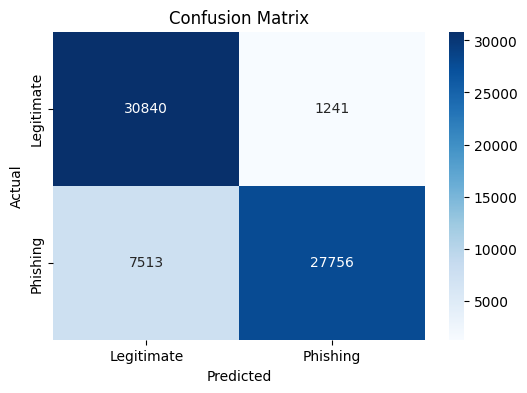

In [11]:
cm = confusion_matrix(y_test_https, y_pred_https)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Results from Experiment 1
Our logical regression model achieved 87% accuracy in identifying phisihing URLs based on only lexical features. The model
demonstrated high phishing precision (96%), but moderate recll(76%). Indicating the regression model's strong confidence in
detecting phishing URLs, but with some missed detections.

## Finding Which Features Are Strong In Detection - Logistical Regression Coefficients
In the next cell, we are going to run an analysis to find the lexical feature that the carries the most significance in the
logical regression model's detection of a phishing URL.

In [12]:
importance = pd.DataFrame({
    'feature': features,
    'weight': model.coef_[0]
}).sort_values(by='weight', ascending=False)

print(importance)

       feature    weight
5    has_login  5.985495
6   has_verify  3.412844
3   num_digits  1.560089
2  num_hyphens  1.115661
0   url_length  0.049377
1     num_dots  0.049377
4    has_https -8.465669


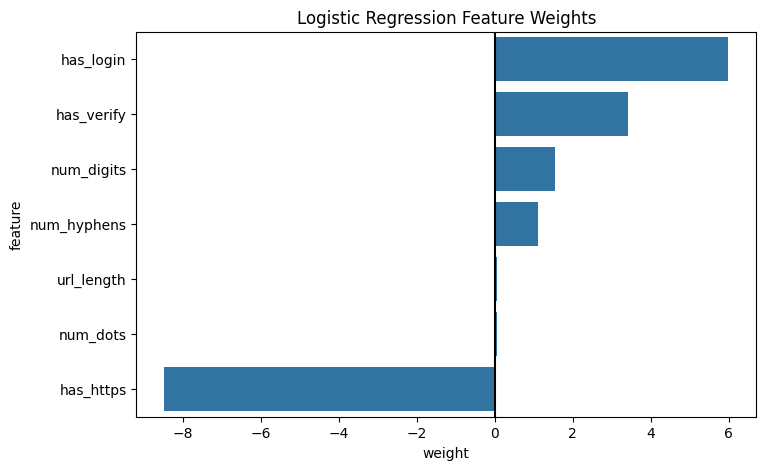

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='weight', y='feature')
plt.title('Logistic Regression Feature Weights')
plt.axvline(0, color='black')
plt.show()

The logistical regression coefficients indicate the lexical features, such as 'login' and 'verify' are strong predictors in detecting 
phishing URLs. While the prescence of 'HTTPS' is has no relevance in phishing URLs and is largely associated with legitimate URLs in the dataset.
Structural features such as URL dot or length have minimal contribution to phishing URL classification. 

### Note
Its important recognize that while HTTPS is heavily associated with legitimate URLs, phishing URLs can also contain them as well. Mainly to trick 
users into thinking a URL link is encrypted. This observation could mean our model may have a bias toward associating HTTPS with legitimate URLs or 
we are working with an older dataset. 

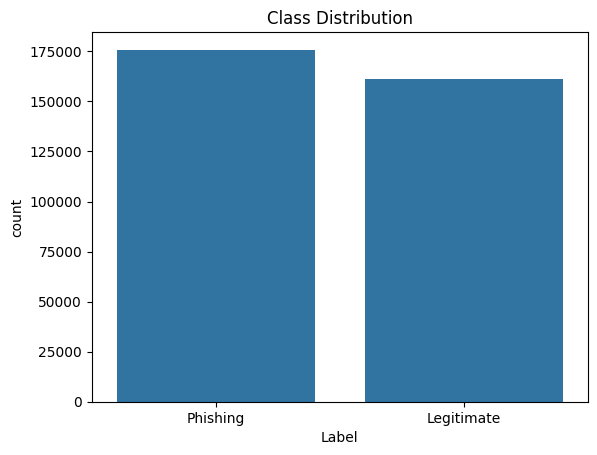

In [14]:
sns.countplot(x=df['Label'])
plt.title("Class Distribution")
plt.show()

## Logical Regression Classifier - ROC

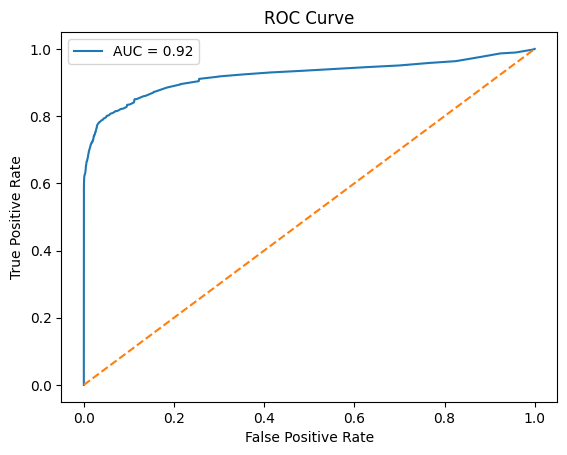

In [15]:
y_probs_https = model.predict_proba(X_test_https)[:,1]
fpr, tpr, _ = roc_curve(y_test_https, y_probs_https)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Analysis
The logistic regression classifier achieved AUC of 0.92, indicating strong separability between phsishing and legitimate URLs using engineered lexical features alone. This suggests that simple string-level characteristics provide substantial predictive power.

## Altered ML Model Threshold For HTTPS

In [18]:
y_probs_https_recall = model.predict_proba(X_test_https)[:,1]
y_pred_adjusted = (y_probs_https_recall > 0.35).astype(int)

print(classification_report(y_test_https, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86     32081
           1       0.90      0.83      0.87     35269

    accuracy                           0.86     67350
   macro avg       0.87      0.87      0.86     67350
weighted avg       0.87      0.86      0.87     67350



## Question
What if we trained the logistical regresson model without HTTPS?

# Experiment 2
In experiment 2, we'll be testing to measure how much bias the regression model has with HTTPS as a lexical feature. If recall decreases, then
HTTPS carried a lot of weight in identifying a phishing URL.

In [19]:
features_no_https = [
    'url_length',
    'num_dots',
    'num_hyphens',
    'num_digits',
    'has_login',
    'has_verify'
]

x = df[features_no_https]
y = df['Label'].map({'Legitimate': 0, 'Phishing': 1})

In [20]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_2 = LogisticRegression()
model_2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred_2 = model_2.predict(X_test)

print(classification_report(y_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.73      0.93      0.82     32081
           1       0.92      0.69      0.79     35269

    accuracy                           0.80     67350
   macro avg       0.82      0.81      0.80     67350
weighted avg       0.83      0.80      0.80     67350



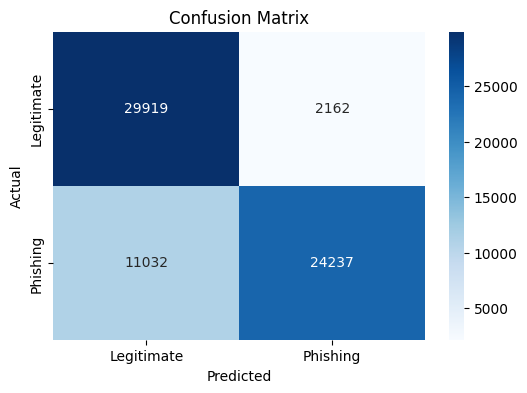

In [22]:
cm = confusion_matrix(y_test, y_pred_2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
df.groupby('Label')['has_https'].mean()

Label
Legitimate    0.999888
Phishing      0.710727
Name: has_https, dtype: float64

## What The Measurement of Dataset Means
The lexical feature, HTTPS is highly associated with legitimate URLs in the dataset (99.999% vs 71%).

In [24]:
importance_2 = pd.DataFrame({
    'feature': features_no_https,
    'weight': model_2.coef_[0]
}).sort_values(by='weight', ascending=False)

print(importance_2)

       feature    weight
4    has_login  5.757928
5   has_verify  3.531993
3   num_digits  1.353146
2  num_hyphens  1.020767
1     num_dots  0.031564
0   url_length  0.031564


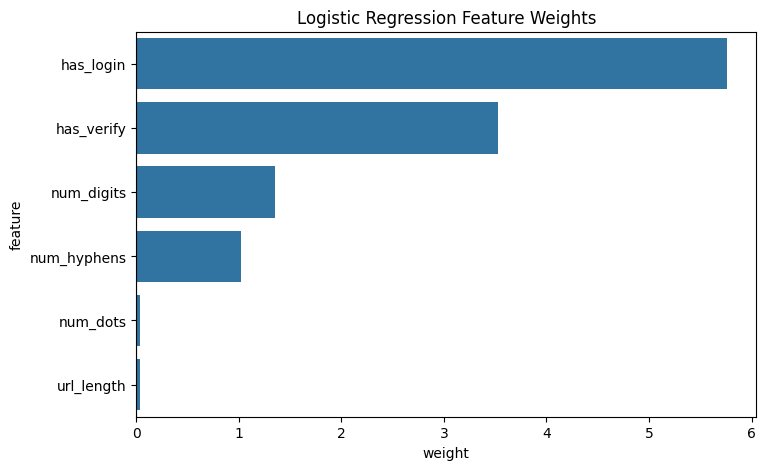

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance_2, x='weight', y='feature')
plt.title('Logistic Regression Feature Weights')
plt.axvline(0, color='black')
plt.show()

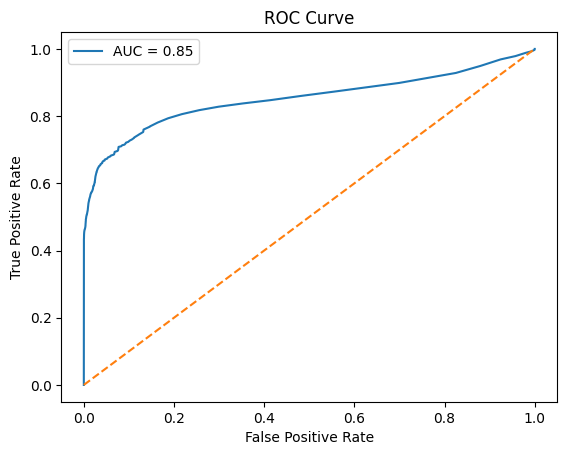

In [26]:
y_probs_2 = model_2.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs_2)
roc_auc_2 = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_2:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Analysis
In removing the HTTPS feature, results demonstrated a decrease in AUC from 0.92 to 0.85 and a 10% drop in phishing recall, indicating that HTTPS is a strong discriminative feature in this dataset. However, reliance on HTTPS may limit generalization to modern phishing attack where HTTPS usage is common.

## Altered ML Model Threshold For No HTTPS

In [27]:
y_probs = model_2.predict_proba(X_test)[:,1]
y_pred_adjusted = (y_probs > 0.35).astype(int)

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81     32081
           1       0.84      0.78      0.81     35269

    accuracy                           0.81     67350
   macro avg       0.81      0.81      0.81     67350
weighted avg       0.81      0.81      0.81     67350

